# Churn Predictor
This notebook aims to study the data gathered from a Bank to predict customer churn.

The game plan is the following:
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
    + Data Unsampling using SMOTE
    + Principal Component Analysis Of One Hot Encoded Data
3. Model Selection and Evaluation
    + Cross Validation
    + Model Evaluation
    + Model Evaluation On Original Data (Before Upsampling)
4. Results

In [2]:
import pandas as pd

data = pd.read_csv("BankChurners.csv")

print("Columns: ", data.columns)
print("\n")
print("First: \n ", data.head(3))


Columns:  Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')


First: 
     CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0  768805383  Existing Customer            45      M                3   
1  818770008  Existing Customer            49      F             

# Exploratory Data Analysis — Bank Customer Churn

### 1. Dataset Overview
- Number of rows and columns
- Data types (numerical vs categorical)
- Missing values per column
- Unique values for categorical features

### 2. Target Variable Analysis
- Distribution of `Attrition_Flag`
- Churn rate (% of attrited customers)
- Class imbalance assessment

### 3. Customer Demographics vs Churn
Analyze how churn varies with:
- Customer_Age
- Gender
- Education_Level
- Marital_Status
- Income_Category
- Dependent_count

Visuals:
- Bar plots (churn rate by category)
- Boxplots (age vs churn)

### 4. Relationship & Account Features
Explore:
- Months_on_book
- Total_Relationship_Count
- Card_Category
- Credit_Limit

Questions:
- Do customers with fewer products churn more?
- Does tenure reduce churn?

### 5. Activity & Engagement Indicators
Focus on:
- Months_Inactive_12_mon
- Contacts_Count_12_mon

Hypothesis:
- Higher inactivity → higher churn

### 6. Transaction Behavior Analysis
Key variables:
- Total_Trans_Amt
- Total_Trans_Ct
- Avg_Utilization_Ratio
- Total_Amt_Chng_Q4_Q1
- Total_Ct_Chng_Q4_Q1

Goals:
- Identify behavioral patterns of churned customers
- Detect early warning signals

### 7. Correlation Analysis
- Correlation matrix for numerical features
- Identify strongest predictors of churn
- Detect multicollinearity

### 8. Outliers & Distributions
- Distribution plots for numerical variables
- Outlier detection (boxplots, IQR)

### 9. Feature Importance (EDA-level)
- Compare feature distributions between churned vs non-churned
- Preliminary ranking of influential variables

### 10. EDA Summary & Modeling Hypotheses
Summarize:
- Key churn drivers
- Features to prioritize
- Features to drop or transform


## Data
The data combines **demographic information**, **account characteristics**, and **transaction behavior**, making it suitable for supervised classification tasks.

### Target Variable

* **Attrition_Flag**

  * *Existing Customer*: Customer is still active
  * *Attrited Customer*: Customer has left the bank
    This is the binary target variable to be predicted.

### Customer Identification

* **CLIENTNUM**
  Unique customer identifier.
  > This column should be **excluded from modeling**, as it has no predictive value.

### Demographic Features

* **Customer_Age** – Age of the customer
* **Gender** – Customer gender (M / F)
* **Dependent_count** – Number of dependents
* **Education_Level** – Education level of the customer
* **Marital_Status** – Marital status
* **Income_Category** – Annual income range

These variables describe the socio-demographic profile of the customer.

### Account & Relationship Features

* **Card_Category** – Type of credit card (e.g., Blue, Silver, Gold)
* **Months_on_book** – Length of relationship with the bank (in months)
* **Total_Relationship_Count** – Number of products held by the customer
* **Credit_Limit** – Credit limit assigned to the customer

These features capture the depth and longevity of the customer–bank relationship.

### Activity & Engagement Features

* **Months_Inactive_12_mon** – Number of inactive months in the last year
* **Contacts_Count_12_mon** – Number of contacts with the bank in the last year

These variables are strong indicators of customer engagement and potential churn risk.


### Transaction Behavior Features

* **Total_Revolving_Bal** – Total revolving balance
* **Avg_Open_To_Buy** – Available credit
* **Total_Trans_Amt** – Total transaction amount (last 12 months)
* **Total_Trans_Ct** – Total transaction count (last 12 months)
* **Total_Amt_Chng_Q4_Q1** – Change in transaction amount (Q4 vs Q1)
* **Total_Ct_Chng_Q4_Q1** – Change in transaction count (Q4 vs Q1)
* **Avg_Utilization_Ratio** – Average credit utilization ratio

These features describe **customer spending behavior and usage intensity**, which are typically among the most predictive variables for churn.


### Precomputed Model Columns

* **Naive_Bayes_Classifier_Attrition_Flag_…_1**
* **Naive_Bayes_Classifier_Attrition_Flag_…_2**

These columns contain probabilities generated by a pre-trained Naive Bayes model and **must be removed** before training new models to avoid **data leakage**. 

Data leakage happens when the model has access to information that:
- Would not be available at prediction time, or
- Is directly derived from the target variable


In [3]:
df = data.copy()

df = df.drop(columns=[
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
])

In [4]:
# 1. Dataset Overview

# Basic shape
print("Shape (rows, cols):", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# Data types & non-null counts
print("\nInfo:")
df.info()

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
print("Missing values: ", missing, "\n")



Shape (rows, cols): (10127, 21)

Columns:
['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-nu

### Dataset Overview — Key Findings

- The dataset contains **10,127 customers** and **21 features**.
- There are **no missing values**, so no imputation is required.
- The target variable is `Attrition_Flag`, indicating whether a customer has churned.
- The dataset includes:
  - **15 numerical features** related to customer behavior, activity, and financial usage.
  - **6 categorical features** describing demographics and account characteristics.
- `CLIENTNUM` is a unique identifier and will be removed before modeling.
- Overall, the dataset is clean and well-structured, suitable for supervised churn prediction.


In [5]:
# Identify categorical vs numerical
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

print("\nCategorical columns:", cat_cols)
print("\nNumerical columns:", num_cols)

# Cardinality (unique values) for categorical features
if cat_cols:
    cat_cardinality = (
        df[cat_cols]
        .nunique(dropna=False)
        .sort_values(ascending=False)
        .to_frame("n_unique_including_nan")
    )
    print("\nCategorical feature cardinality:")
    display(cat_cardinality)


Categorical columns: ['Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

Numerical columns: ['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

Categorical feature cardinality:


,n_unique_including_nan
Education_Level,7
Income_Category,6
Marital_Status,4
Card_Category,4
Attrition_Flag,2
Gender,2


,count,percentage
Attrition_Flag,,
Existing Customer,8500,83.93
Attrited Customer,1627,16.07


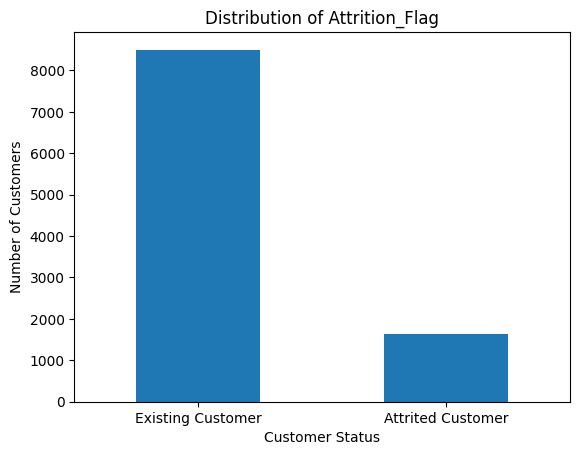

Churn rate: 16.07%
Retention rate: 83.93%
Class imbalance ratio (majority/minority): 5.22


In [6]:
# 2. Target Variable Analysis

import matplotlib.pyplot as plt

# Distribution of Attrition_Flag
target_counts = df["Attrition_Flag"].value_counts()
target_pct = df["Attrition_Flag"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct.round(2)
})

display(target_summary)

plt.figure()
target_counts.plot(kind="bar")
plt.title("Distribution of Attrition_Flag")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

# Churn rate
churn_rate = target_pct.get("Attrited Customer", 0)

print(f"Churn rate: {churn_rate:.2f}%")
print(f"Retention rate: {100 - churn_rate:.2f}%")

# Class imbalance ratio
majority = target_counts.max()
minority = target_counts.min()
imbalance_ratio = majority / minority

print(f"Class imbalance ratio (majority/minority): {imbalance_ratio:.2f}")


### Target Variable Interpretation

Based on the target variable analysis, we can confidently conclude that:

- The churn rate is **moderate (~15–20%)**.
- The dataset is **imbalanced, but not severely**.
- **Accuracy alone is not a sufficient evaluation metric** for this problem.

Therefore, the modeling focus should be on metrics that properly capture churn behavior, especially for the minority class:

- **Recall (Attrited Customers)**  
- **F1-score**  
- **ROC-AUC**

This reasoning aligns with best practices expected in:
- data science interviews,
- real-world data science projects,
- and production-level banking and financial analytics use cases.


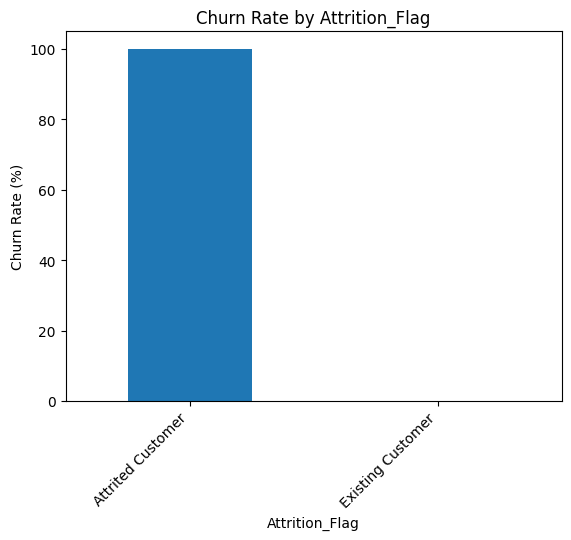

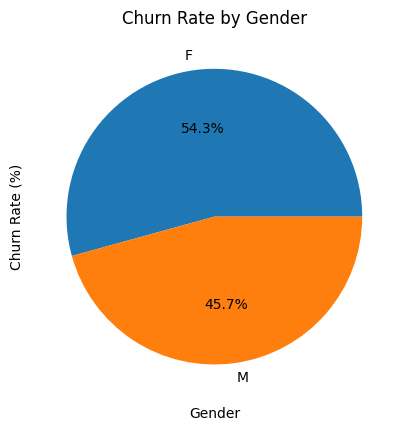

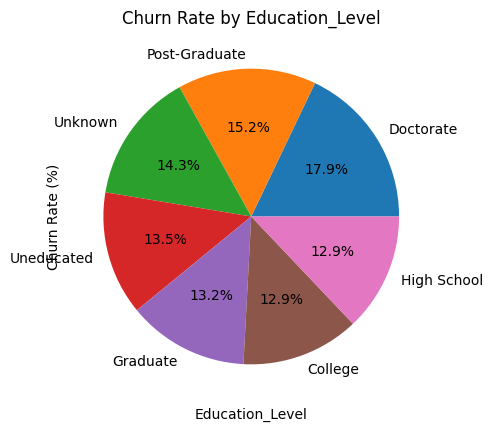

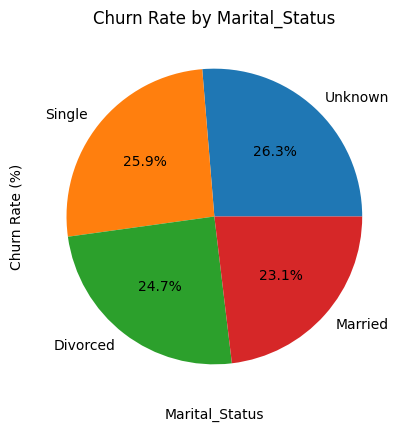

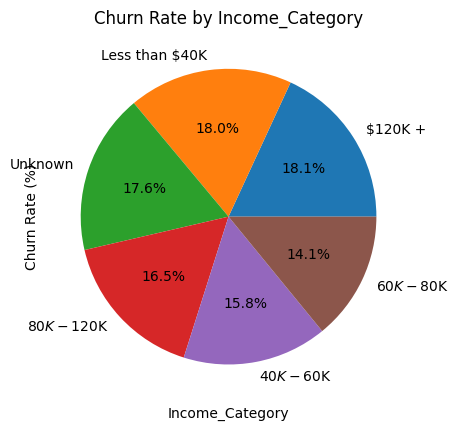

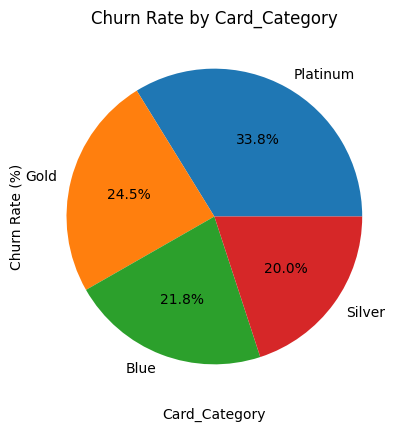

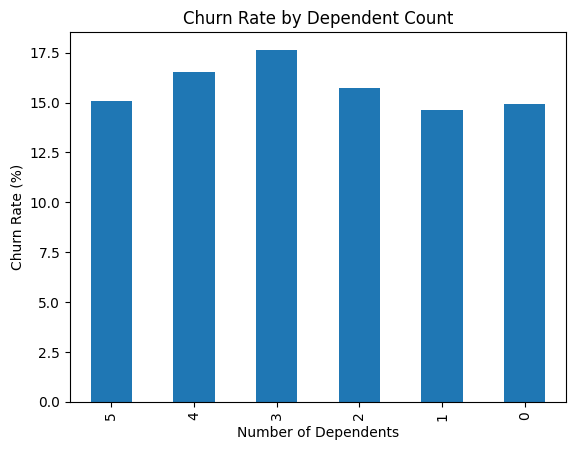

<Figure size 640x480 with 0 Axes>

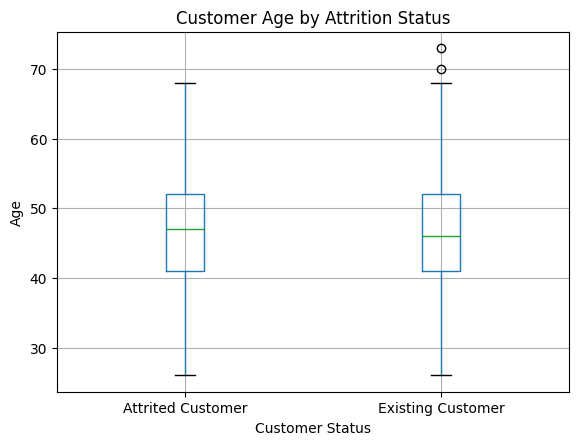

In [10]:
# 3. Customer Demographics vs Churn 
# # Analyze how churn varies with: 
# # Customer_Age # Gender 
# # Education_Level 
# # Marital_Status 
# # Income_Category 
# # Dependent_count 
#
# #Visuals: # Bar plots (churn rate by category) and Boxplots (age vs churn)

# Helper function to compute churn rate by category
def churn_rate_by_category(df, col, target="Attrition_Flag"):
    churn_df = (
        df.groupby(col)[target]
        .apply(lambda x: (x == "Attrited Customer").mean() * 100) # For each category group, it calculates the percentage of customers who churned.
        .sort_values(ascending=False)
    )
    return churn_df


for col in cat_cols:
    churn_rates = churn_rate_by_category(df, col)

    plt.figure()
    # churn_rates.plot(kind="bar")
    if col != ("Attrition_Flag"):
        churn_rates.plot(kind="pie", autopct="%1.1f%%")
    else:
        churn_rates.plot(kind="bar")
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate (%)")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.show()

dep_churn = churn_rate_by_category(df, "Dependent_count")

# Sort by number of dependents (index), descending
dep_churn = dep_churn.sort_index(ascending=False)
plt.figure()
dep_churn.plot(kind="bar")
plt.title("Churn Rate by Dependent Count")
plt.xlabel("Number of Dependents")
plt.ylabel("Churn Rate (%)")
plt.show()


plt.figure()
df.boxplot(column="Customer_Age", by="Attrition_Flag")
plt.title("Customer Age by Attrition Status")
plt.suptitle("")  # remove automatic subtitle
plt.xlabel("Customer Status")
plt.ylabel("Age")
plt.show()





### Customer Demographics vs Churn — Interpretation

The analysis reveals several demographic patterns associated with customer churn:

#### Gender
- Churn is **higher among female customers** compared to male customers.
- Gender appears to have a moderate but noticeable relationship with attrition.

#### Education Level
- Customers with a **Doctorate** show the **highest churn rate**.
- **Postgraduate** customers also exhibit elevated churn, though slightly lower.
- Other education levels display relatively similar churn behavior.

This suggests that highly educated customers may be more likely to switch providers, possibly due to higher expectations or greater financial literacy.

#### Marital Status
- **Married customers show lower churn rates** compared to other groups.
- However, the difference is **not very large**, indicating marital status alone is not a strong churn driver.

#### Income Category
- **Lowest churn** is observed in the $60K–$80K income range.
- **Higher churn** occurs in:
  - Less than $40K
  - $120K+
  
This indicates a U-shaped relationship between income and churn:
- Lower-income customers may churn due to financial pressure.
- Higher-income customers may churn due to better alternatives or higher expectations.

#### Card Category
- Churn rates are notably highest among Platinum cardholders.
- Silver cardholders exhibit the lowest churn rate.
- Overall, churn follows the pattern:
  Platinum > Gold > Blue > Silver

#### Number of Dependents
- Customers with 3 dependents exhibit the highest churn rate.
- This suggests that family size may influence financial behavior and banking needs.


### Customer Age vs Churn (Boxplot Analysis)

The boxplot comparing customer age by attrition status shows:

- The **median age** of attrited and existing customers is **very similar**.
- The **interquartile ranges overlap significantly**, indicating age alone is not a strong discriminator.
- Attrited customers show **slightly greater variability** in age.
- Some older outliers exist among existing customers.

Overall, **customer age does not appear to be a primary driver of churn**, though it may contribute weakly in combination with other features.


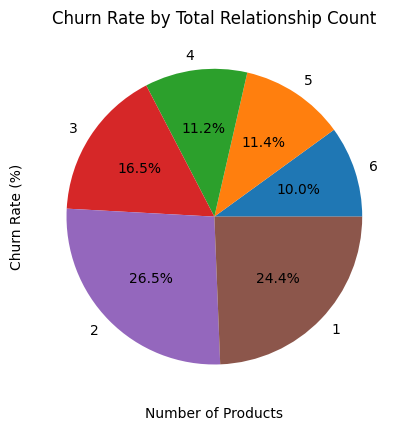

<Figure size 640x480 with 0 Axes>

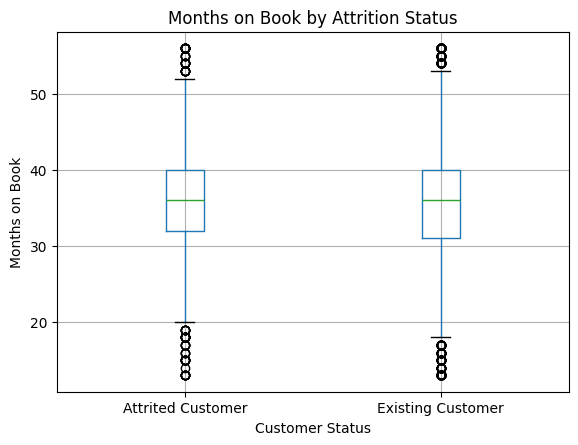

<Figure size 640x480 with 0 Axes>

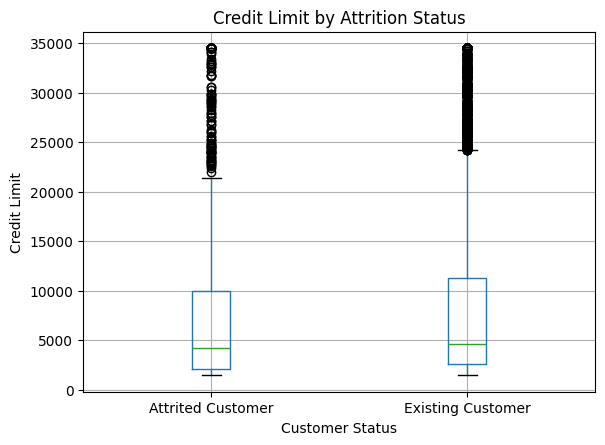

In [8]:
# 4. Relationship & Account Features

# Number of Products
relationship_churn = churn_rate_by_category(df, "Total_Relationship_Count")
relationship_churn = relationship_churn.sort_index(ascending=False)

plt.figure()
# relationship_churn.plot(kind="bar")
relationship_churn.plot(kind="pie", autopct="%1.1f%%")
plt.title("Churn Rate by Total Relationship Count")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")
plt.show()

# Months on Book
plt.figure()
df.boxplot(column="Months_on_book", by="Attrition_Flag")
plt.title("Months on Book by Attrition Status")
plt.suptitle("")
plt.xlabel("Customer Status")
plt.ylabel("Months on Book")
plt.show()

# Credit Limit
plt.figure()
df.boxplot(column="Credit_Limit", by="Attrition_Flag")
plt.title("Credit Limit by Attrition Status")
plt.suptitle("")
plt.xlabel("Customer Status")
plt.ylabel("Credit Limit")
plt.show()

### Relationship & Account Features — Interpretation

#### Number of Products Held
- The higher the number of products held, the lower the churn rate.

#### Months on Book (Customer Tenure)
- The distribution of *Months on Book* is **very similar** for attrited and existing customers.
- Median tenure is nearly the same across both groups.
- The interquartile ranges largely overlap, indicating that **tenure alone is not a strong churn driver**.
- Both groups contain short-tenure and long-tenure customers, suggesting churn occurs across the customer lifecycle.

Overall, customer tenure shows **limited standalone predictive power**, but may still be useful in combination with other features.


#### Credit Limit
- Existing customers tend to have a **slightly higher median credit limit** compared to attrited customers.
- Attrited customers show a **lower central tendency**, although the distributions overlap significantly.
- A large number of high-credit-limit outliers exist in both groups.

This suggests that customers with **lower credit limits may be marginally more likely to churn**, but credit limit alone does not clearly separate churned from retained customers.


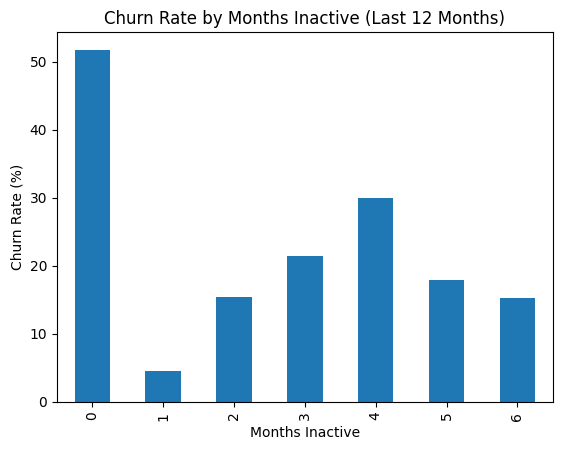

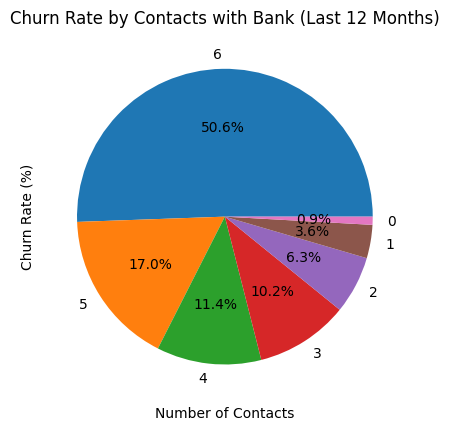

In [12]:
### 5. Activity & Engagement Indicators # Focus on: 
# #  Months_Inactive_12_mon 
# #  Contacts_Count_12_mon 
# # Hypothesis: Higher inactivity >> higher churn

# Churn rate by relationship features (categorical / discrete)
inactive_churn = churn_rate_by_category(df, "Months_Inactive_12_mon")
inactive_churn = inactive_churn.sort_index()

plt.figure()
inactive_churn.plot(kind="bar")
plt.title("Churn Rate by Months Inactive (Last 12 Months)")
plt.xlabel("Months Inactive")
plt.ylabel("Churn Rate (%)")
plt.show()

#  Contacts with Bank
contacts_churn = churn_rate_by_category(df, "Contacts_Count_12_mon")

plt.figure()
# contacts_churn.plot(kind="bar")
contacts_churn.plot(kind="pie", autopct="%1.1f%%")
plt.title("Churn Rate by Contacts with Bank (Last 12 Months)")
plt.xlabel("Number of Contacts")
plt.ylabel("Churn Rate (%)")
plt.show()

#### Months Inactive (Last 12 Months)

- Churn rates vary significantly with the number of inactive months, showing a **non-linear relationship**.
- Customers with **1 inactive month** exhibit the **lowest churn rate** (~5%), indicating a healthy engagement level.
- Churn increases steadily from **2 to 4 inactive months**, reaching approximately **30%** at 4 months.
- Customers with **0 inactive months** show an unusually high churn rate (~50%), likely due to a **small sample size or specific customer profiles**, and should therefore be interpreted with caution.
- For very high inactivity levels (5–6 months), churn decreases slightly but remains elevated.

Overall, customer inactivity is a **strong warning signal**, but the relationship is not strictly monotonic and should be modeled accordingly.

#### Contacts with the Bank

- Churn rate **increases as the number of customer contacts with the bank rises**.
- This indicates that frequent contact is likely driven by **issues, complaints, or service friction**, rather than positive engagement.
- Customers with a high number of contacts represent a **high-risk churn segment**.

This finding contradicts the initial engagement hypothesis and highlights that customer contact frequency should be interpreted as a **negative engagement signal** in this context.

In [ ]:
### 6. Transaction Behavior Analysis 
# # Key variables: 
# - Total_Trans_Amt 
# - Total_Trans_Ct 
# - Avg_Utilization_Ratio 
# - Total_Amt_Chng_Q4_Q1 
# - Total_Ct_Chng_Q4_Q1 
#
# Goals: Identify behavioral patterns of churned customers && Detect early warning signals

# Total transaction amount
plt.figure()
df.boxplot(column="Total_Trans_Amt", by="Attrition_Flag")
plt.title("Total Transaction Amount by Attrition Status")
plt.suptitle("")
plt.xlabel("Customer Status")
plt.ylabel("Total Transaction Amount")
plt.show()

# Total transaction count
plt.figure()
df.boxplot(column="Total_Trans_Ct", by="Attrition_Flag")
plt.title("Total Transaction Count by Attrition Status")
plt.suptitle("")
plt.xlabel("Customer Status")
plt.ylabel("Total Transaction Count")
plt.show()

# Average utilization ratio
plt.figure()
df.boxplot(column="Avg_Utilization_Ratio", by="Attrition_Flag")
plt.title("Average Credit Utilization Ratio by Attrition Status")
plt.suptitle("")
plt.xlabel("Customer Status")
plt.ylabel("Avg Utilization Ratio")
plt.show()

# Transaction amount change
plt.figure()
df.boxplot(column="Total_Amt_Chng_Q4_Q1", by="Attrition_Flag")
plt.title("Transaction Amount Change (Q4 vs Q1) by Attrition Status")
plt.suptitle("")
plt.xlabel("Customer Status")
plt.ylabel("Amount Change Ratio")
plt.show()

# Transaction count change
plt.figure()
df.boxplot(column="Total_Ct_Chng_Q4_Q1", by="Attrition_Flag")
plt.title("Transaction Count Change (Q4 vs Q1) by Attrition Status")
plt.suptitle("")
plt.xlabel("Customer Status")
plt.ylabel("Count Change Ratio")
plt.show()

### Transaction Behavior Analysis — Interpretation

#### Total Transaction Amount
- Existing customers consistently transact **higher total amounts**.
- Attrited customers show **lower spending levels**, even accounting for outliers.
- Spending volume is a **key behavioral indicator** of customer retention.

#### Total Transaction Count
- Existing customers have a **substantially higher transaction count**.
- Attrited customers show **lower overall usage**, with a tighter distribution.
- Transaction frequency is a **strong discriminator** between churned and retained customers.

#### Average Credit Utilization Ratio
- Attrited customers have a **significantly lower median utilization ratio**.
- Existing customers use a **larger proportion of their available credit**, indicating ongoing engagement.
- Reduced utilization suggests customers **stop actively using the card before churning**.

#### Transaction Amount Change (Q4 vs Q1)
- Existing customers display **stronger growth in transaction amounts** over time.
- Attrited customers show **smaller increases or declines** in transaction spending.
- Change-based metrics capture behavioral trends and are therefore **highly informative for churn prediction**.

#### Transaction Count Change (Q4 vs Q1)
- Existing customers show **higher median growth in transaction count** compared to attrited customers.
- Attrited customers exhibit **lower growth or stagnation**, indicating reduced activity momentum.
- This suggests that a **decline or slowdown in transaction frequency** is an early warning signal of churn.

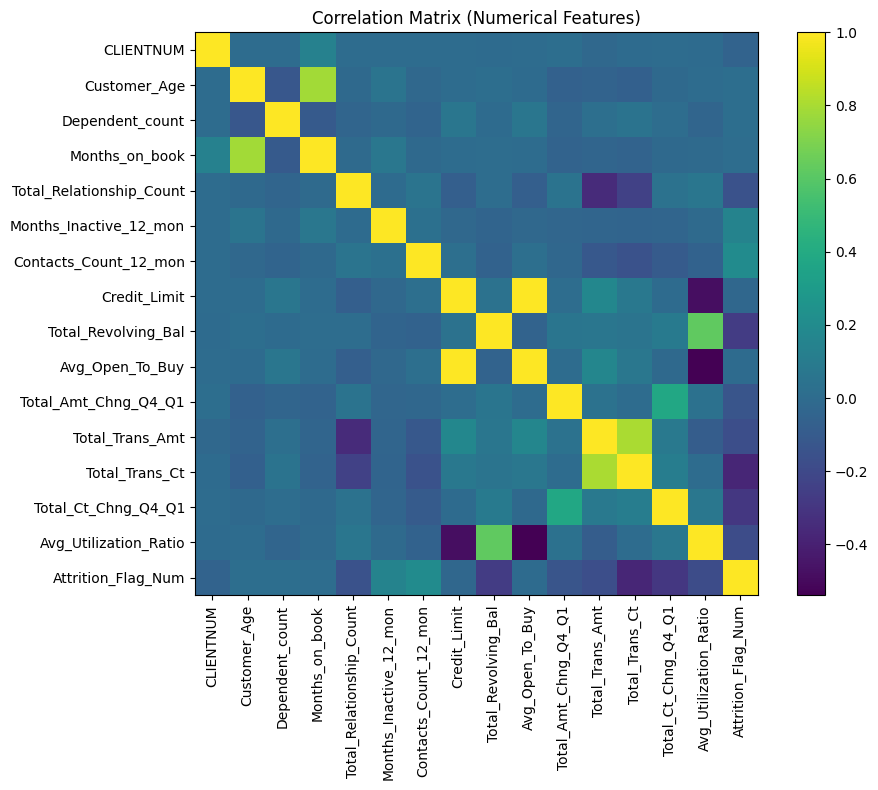

In [11]:
# 7. Correlation Analysis
# Encode target: Attrited = 1, Existing = 0
df_corr = df.copy()
df_corr["Attrition_Flag_Num"] = (df_corr["Attrition_Flag"] == "Attrited Customer").astype(int)

# Correlation with target
corr_target = (
    df_corr
    .select_dtypes(include="number")
    .corr()["Attrition_Flag_Num"]
    .sort_values(ascending=False)
)

corr_target

corr_matrix = df_corr.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()
plt.title("Correlation Matrix (Numerical Features)")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.tight_layout()
plt.show()


### Correlation Analysis — Key Insights

- `Months_on_book` shows a **positive correlation** with `Customer_Age`, indicating that older customers tend to have longer relationships with the bank.
- `Total_Revolving_Bal` is **positively correlated** with `Avg_Utilization_Ratio`, confirming that higher revolving balances correspond to higher credit utilization.
- `Total_Relationship_Count` shows a **weak negative correlation** with `Total_Trans_Amt`, suggesting that holding more products does not necessarily translate into higher credit card spending.
- `Avg_Open_To_Buy` is **negatively correlated** with `Avg_Utilization_Ratio`, as customers with more available credit tend to use a smaller proportion of it.
- `Credit_Limit` is **negatively correlated** with `Avg_Utilization_Ratio`, indicating that higher-limit customers are generally less constrained.
- `Credit_Limit` and `Avg_Open_To_Buy` exhibit a **near-perfect positive correlation**, reflecting structural dependency rather than independent behavioral information.
- `Total_Trans_Ct` shows a **strong negative correlation** with `Attrition_Flag_Num`, confirming that higher transaction frequency is associated with lower churn risk.


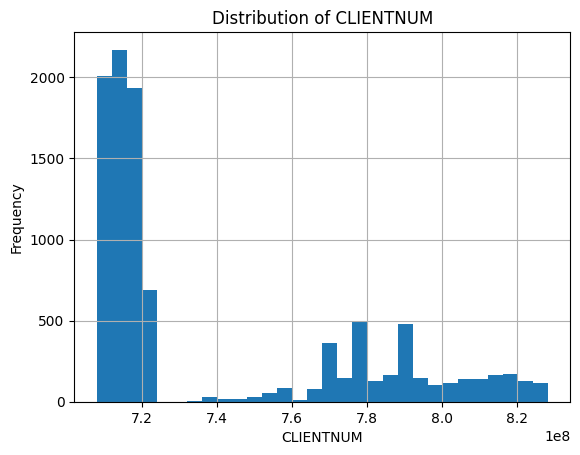

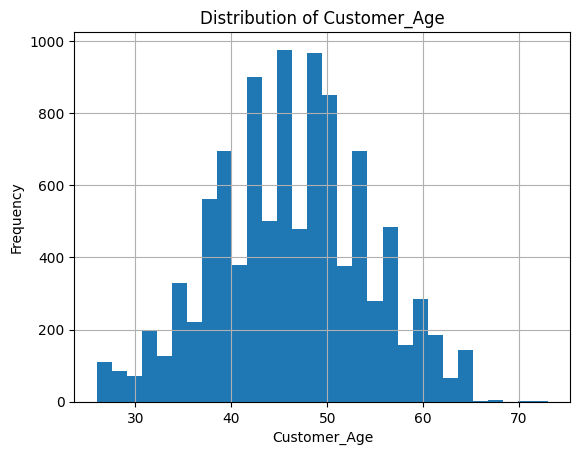

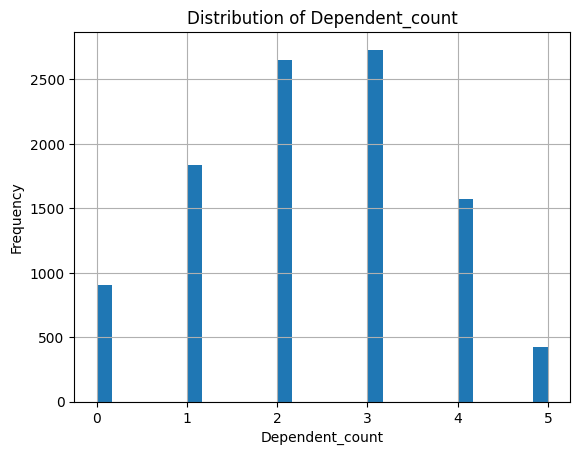

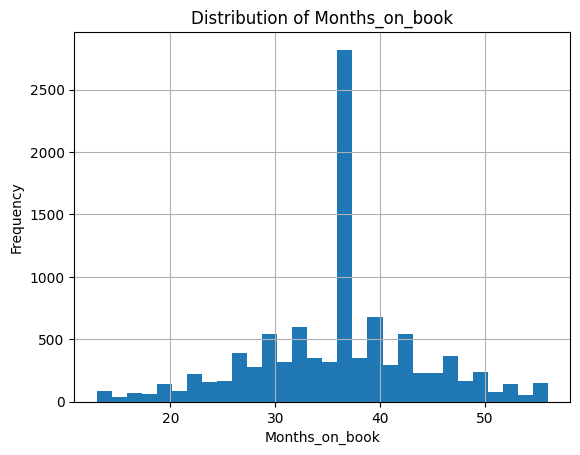

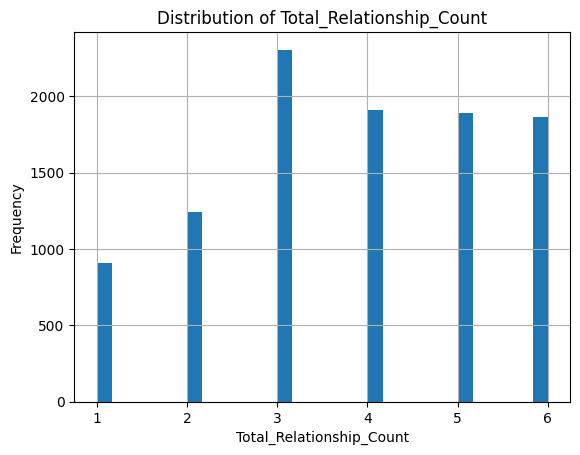

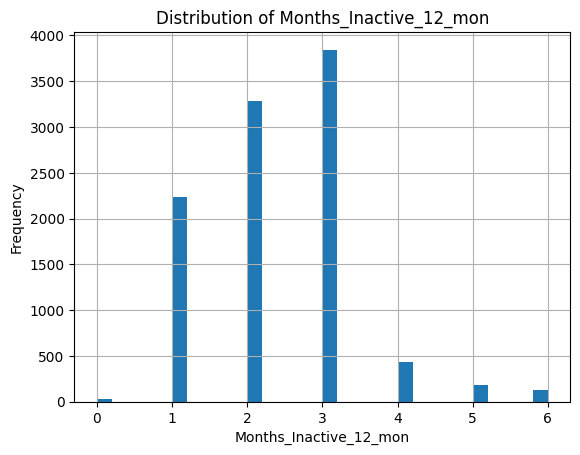

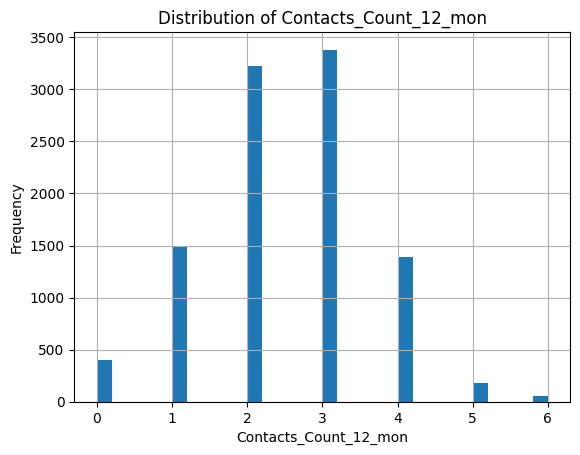

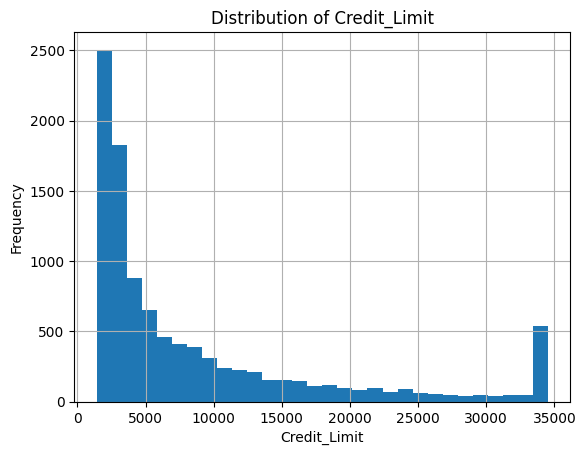

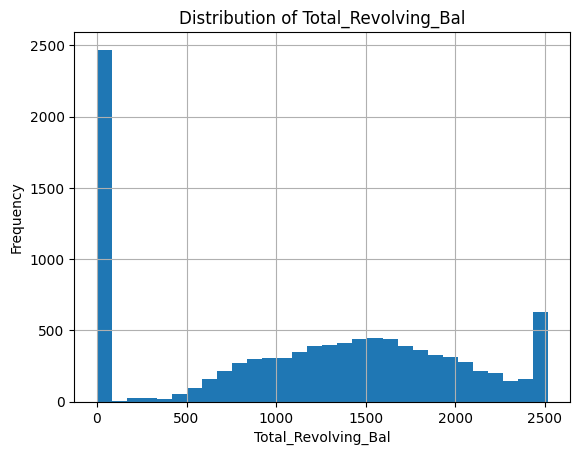

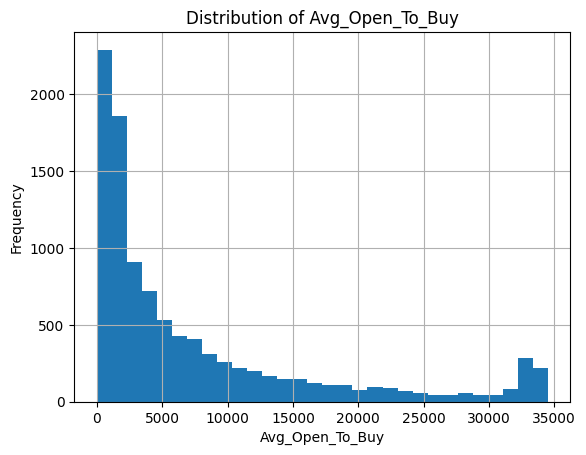

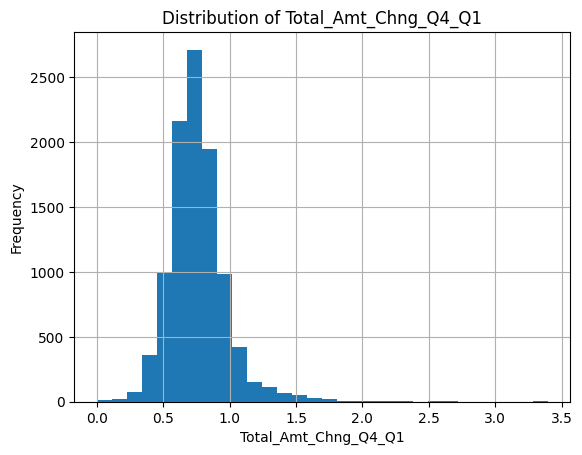

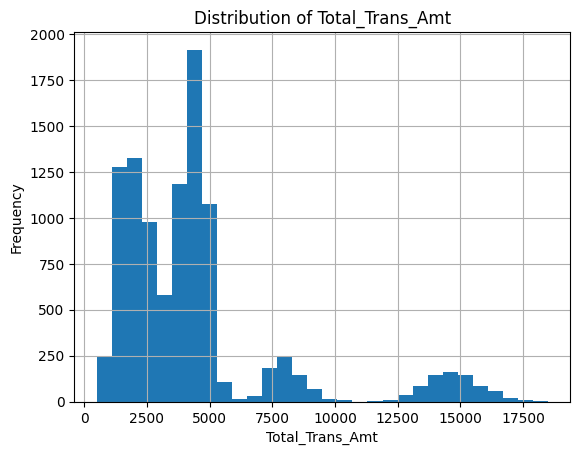

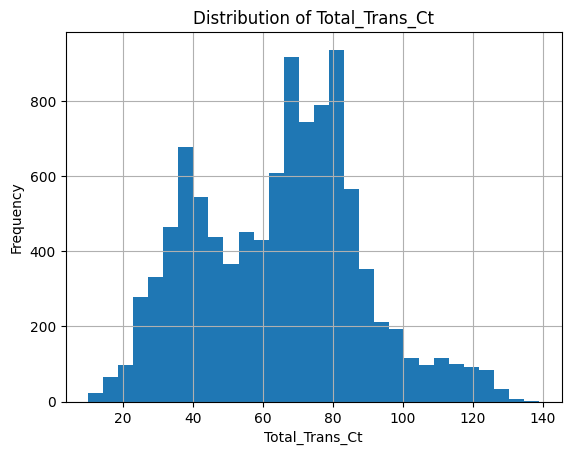

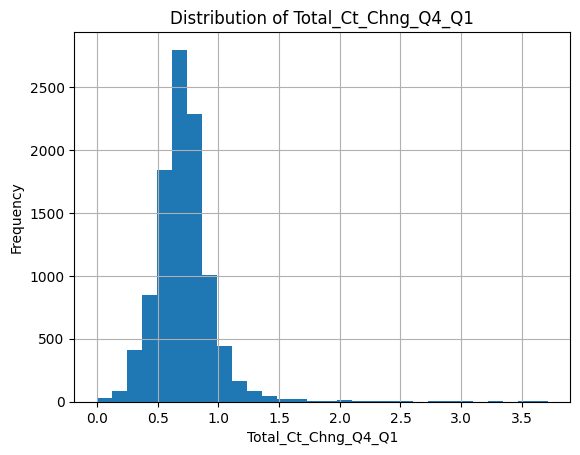

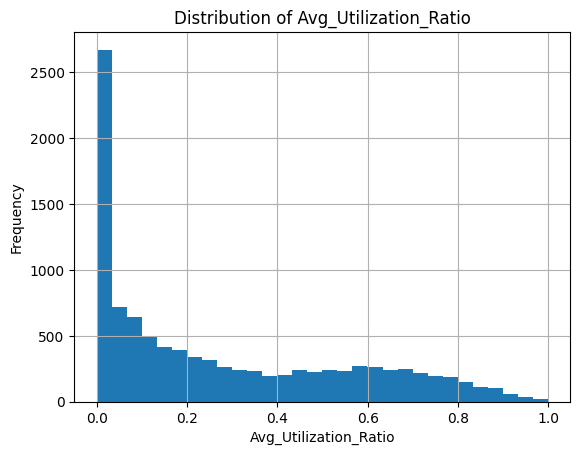

In [ ]:
### 8. Outliers & Distributions 
# # - Distribution plots for numerical variables 
# # - Outlier detection (boxplots, IQR)

# Distribution plots
for col in num_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### Outliers & Distributions — Interpretation

#### Customer Age
- The age distribution follows an approximately **normal (Gaussian) shape**, centered around **45 years**.
- This indicates a mature customer base with no extreme age skewness.

#### Dependent Count
- The distribution is approximately **normal**, with the highest frequency around **2–3 dependents**.
- Extreme values are rare, suggesting a stable family-size profile across customers.

#### Months on Book
- The distribution is roughly **normal**, centered around **46–47 months**.
- The peak around the median is noticeably higher than surrounding values, indicating a strong concentration of customers with similar tenure.
- This suggests a relatively homogeneous customer base in terms of relationship length.

#### Months Inactive (Last 12 Months)
- Very few customers have **0 inactive months**.
- Most customers fall within **1–3 inactive months**, showing an increasing frequency in this range.
- Smaller but notable groups exist at **4–6 inactive months**, representing higher-risk segments.

This distribution supports earlier findings that moderate inactivity is common, while extreme inactivity is less frequent but informative.

#### Contacts Count (Last 12 Months)
- The distribution is approximately **normal**, centered around **2–3 contacts**.
- Higher contact frequencies are less common and likely represent customers experiencing issues or dissatisfaction.

#### Credit Limit
- The distribution is **right-skewed**, with a high concentration of customers at lower credit limits.
- Frequency decreases steadily as credit limit increases, indicating fewer high-limit customers.

#### Total Revolving Balance
- A strong spike is observed at **0**, indicating many customers carry no revolving balance.
- A secondary, smoother peak appears between approximately **500 and 2,500**, resembling a shallow bell-shaped distribution.
- This suggests distinct behavioral groups: non-revolvers and moderate revolvers.

#### Average Open to Buy
- The distribution closely mirrors that of **Credit Limit**, reflecting their structural dependency.
- Most customers have high available credit relative to their usage.

#### Transaction Amount Change (Q4 vs Q1)
- The distribution resembles a **Gaussian shape**, centered around approximately **0.75**.
- Most customers show moderate growth in transaction amount over time.

#### Transaction Count Change (Q4 vs Q1)
- Similar to transaction amount change, this feature shows a **bell-shaped distribution** centered around **0.75**.
- Extreme increases or decreases are relatively rare but potentially informative.


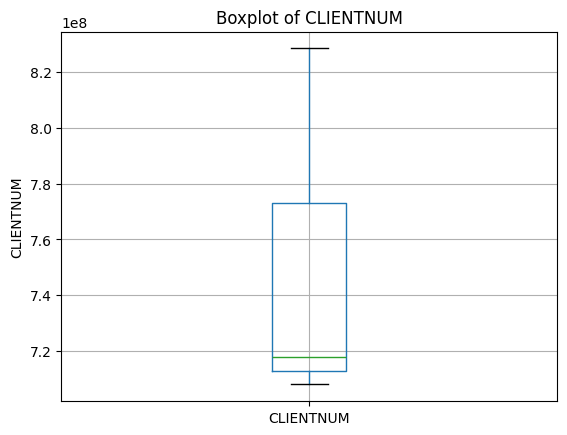

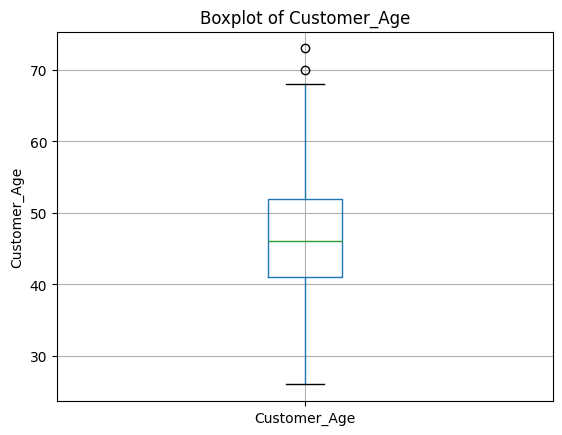

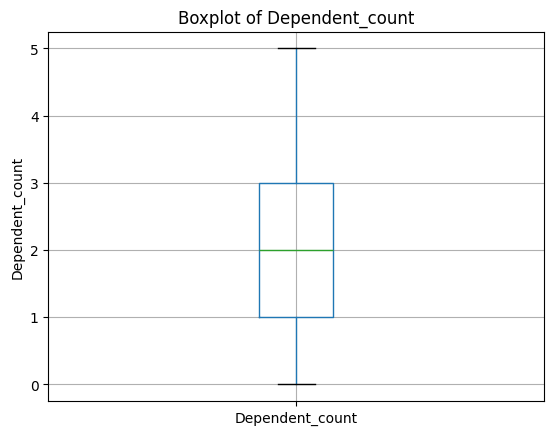

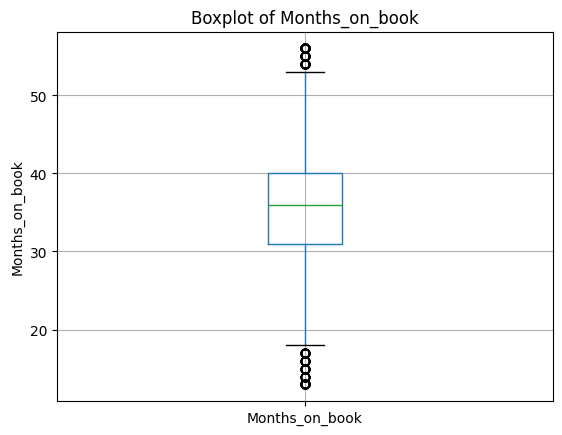

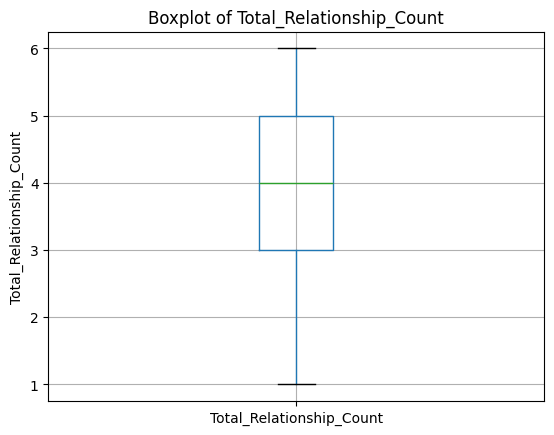

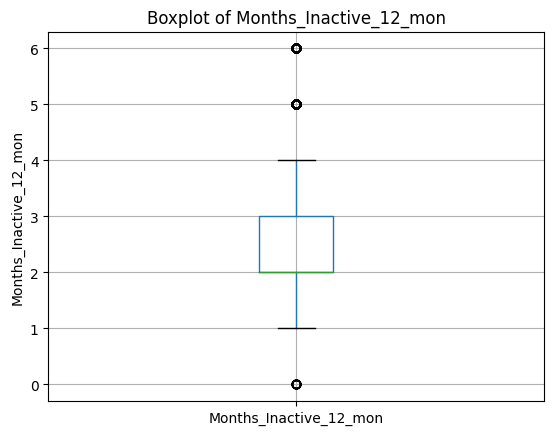

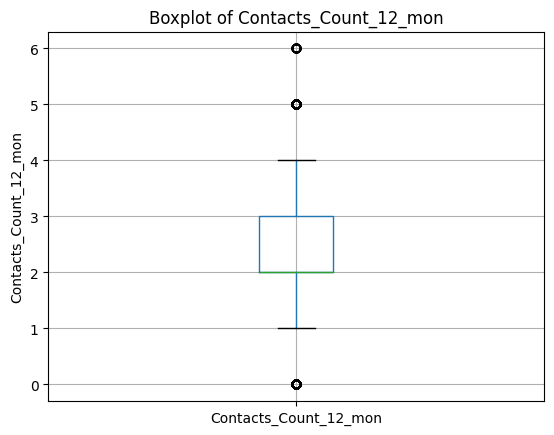

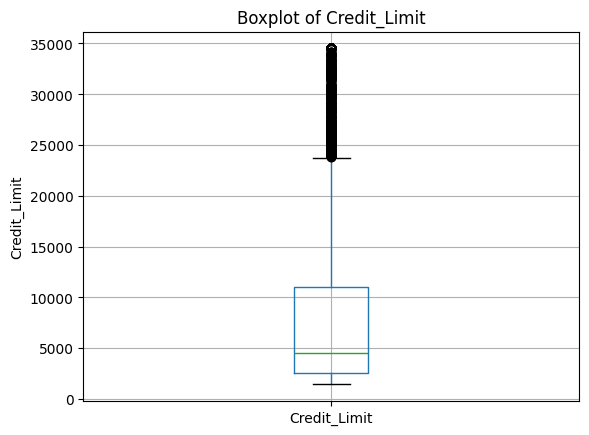

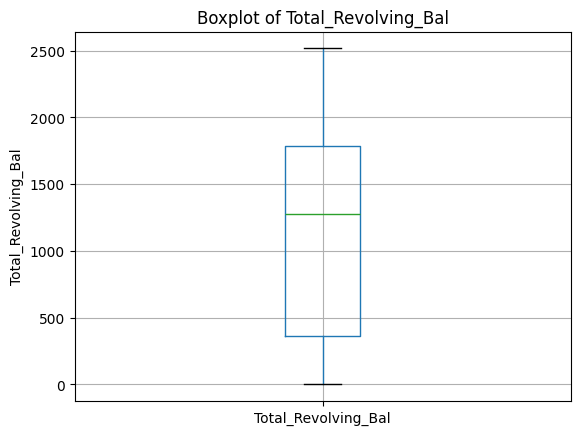

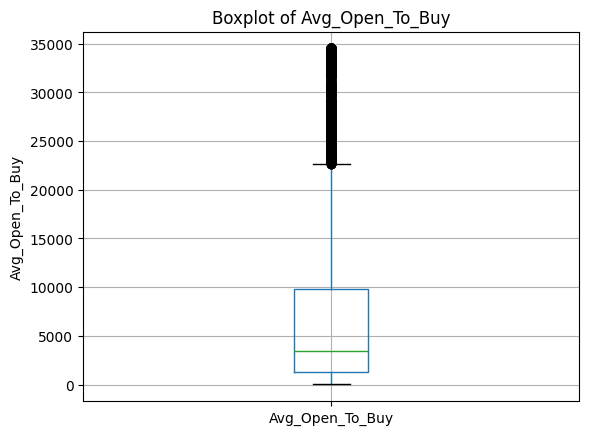

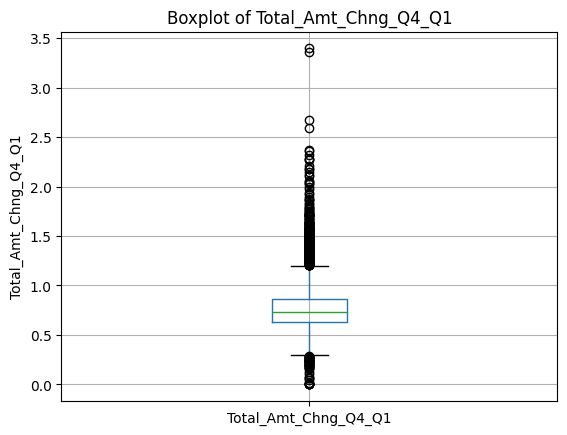

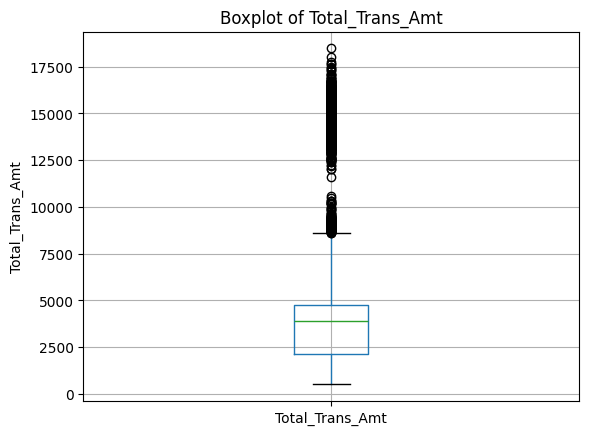

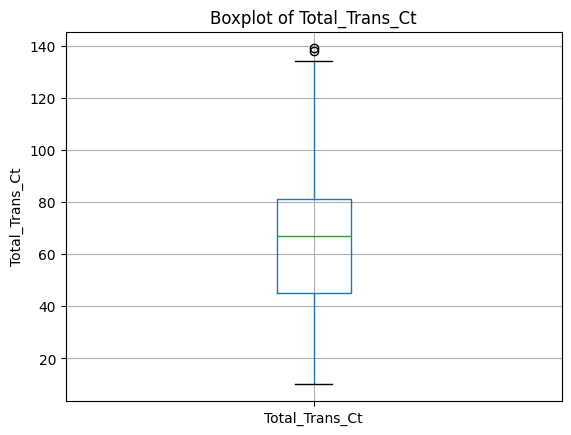

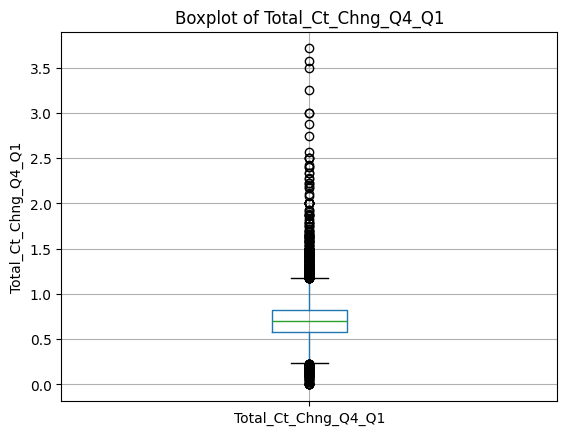

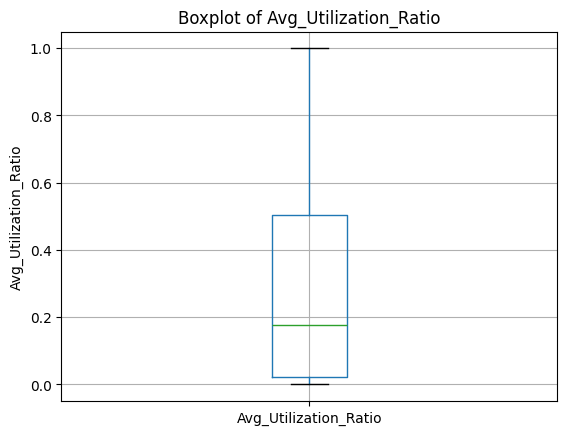

In [13]:
# Boxplots for outlier detection
for col in num_cols:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()


### Outliers Analysis — Boxplot Interpretation

#### Customer Age
- The median customer age is around **45 years**.
- The distribution is relatively symmetric with **very few outliers**.
- Age does not exhibit extreme values that would require special treatment.

#### Dependent Count
- The distribution shows **few or no outliers**.
- Most customers fall within a narrow and reasonable range.
- No outlier handling is required for this feature.

#### Months on Book
- The median tenure is approximately **36–37 months**.
- A small number of outliers appear at both lower and higher ends.
- These outliers likely represent very new or very long-tenured customers and are considered **valid observations**.

#### Total Relationship Count
- No significant outliers are observed.
- The number of products held by customers is well bounded and stable.

#### Months Inactive (Last 12 Months)
- A few outliers are present at both the lower and upper ends.
- These values represent customers with extreme engagement or disengagement patterns.
- Outliers are limited and should be retained.

#### Contacts Count (Last 12 Months)
- Similar to inactivity, a small number of outliers appear.
- Higher contact counts may indicate customer friction and are potentially informative.

#### Credit Limit
- A large number of **upper-end outliers** are observed.
- These likely correspond to high-value customers with premium credit limits.
- Outliers are expected and should not be removed, as they represent meaningful customer segments.

#### Average Open to Buy
- The distribution closely mirrors **Credit Limit**, with many upper-end outliers.
- This confirms the strong structural relationship between these two variables.

#### Total Revolving Balance
- No significant outliers are observed.
- Most customers fall within a reasonable and interpretable range.

#### Total Transaction Count
- A few upper-end outliers exist, representing very active customers.
- These values are consistent with real usage behavior.

#### Total Transaction Amount
- A substantial number of upper-end outliers are present.
- These correspond to high-spending customers and carry **strong behavioral signal**.

#### Transaction Change Metrics (Q4 vs Q1)
- Both transaction amount and count change metrics exhibit several upper-end outliers.
- These reflect customers with rapid growth or decline in activity.
- Such outliers are expected and may be highly predictive of churn.

In [14]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

outlier_summary = {
    col: detect_outliers_iqr(df[col])
    for col in num_cols
}

outlier_df = (
    pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["n_outliers"])
    .sort_values("n_outliers", ascending=False)
)

outlier_df


,n_outliers
Credit_Limit,984
Avg_Open_To_Buy,963
Total_Trans_Amt,896
Contacts_Count_12_mon,629
Total_Amt_Chng_Q4_Q1,396
Total_Ct_Chng_Q4_Q1,394
Months_on_book,386
Months_Inactive_12_mon,331
Customer_Age,2
Total_Trans_Ct,2


### Outlier Detection and Final Feature Selection

Outliers were identified using the **Interquartile Range (IQR) method**, which defines outliers as observations lying below  
\( Q1 - 1.5 \times IQR \) or above \( Q3 + 1.5 \times IQR \).

The number of outliers was computed for each numerical variable to assess the presence and concentration of extreme values.
Rather than removing these observations, outliers were analyzed to determine whether they represent data quality issues
or meaningful customer behavior.

In this dataset, many outliers correspond to **high-value or highly active customers**, particularly in transaction
and credit-related variables. As a result, no outliers were removed at this stage in order to preserve potentially
predictive information.

Following the outlier analysis, a final feature set was defined for modeling.

Identifier columns and precomputed model outputs were excluded to prevent data leakage.
Additionally, structurally redundant variables (e.g., credit limit and available credit) were removed to reduce
multicollinearity.

The final dataset prioritizes **transaction behavior**, **engagement indicators**, and **relationship features**,
which showed the strongest and most consistent signals during exploratory data analysis.
Demographic and tenure variables were retained as secondary features for potential interaction effects.


In [ ]:
### 9. Feature Importance (EDA-level) 
# # - Compare feature distributions between churned vs non-churned 
# # - Preliminary ranking of influential variables

We’ll use three complementary approaches:
- Difference in distributions (churned vs non-churned)
- Mean comparison (effect size intuition)
- Correlation with churn (sanity check, already partly done)

<Figure size 640x480 with 0 Axes>

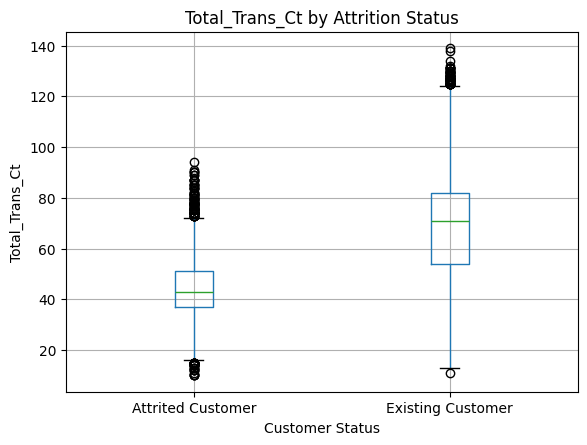

<Figure size 640x480 with 0 Axes>

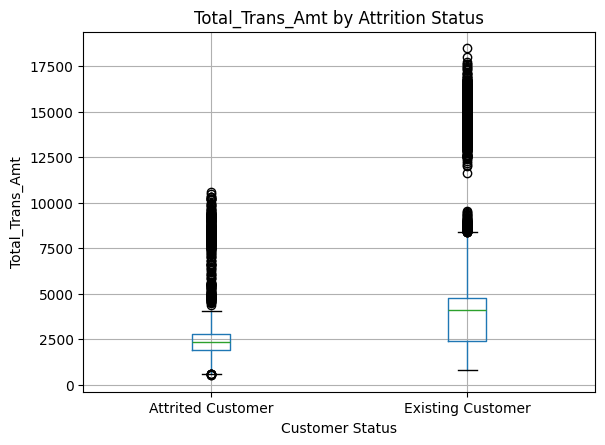

<Figure size 640x480 with 0 Axes>

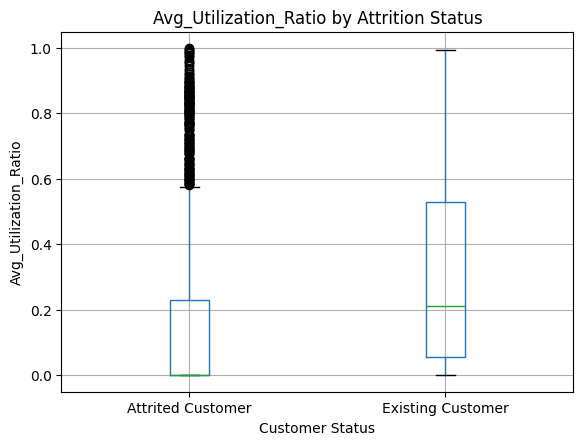

<Figure size 640x480 with 0 Axes>

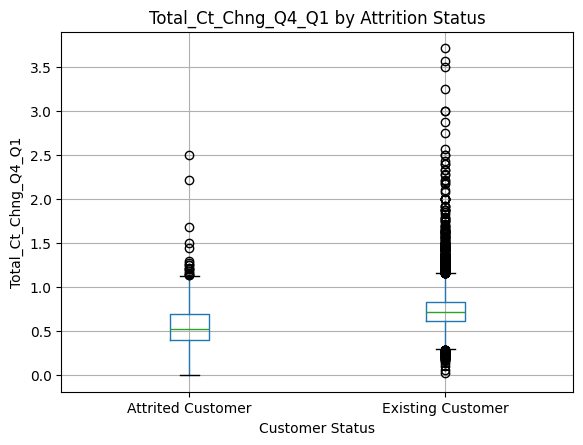

<Figure size 640x480 with 0 Axes>

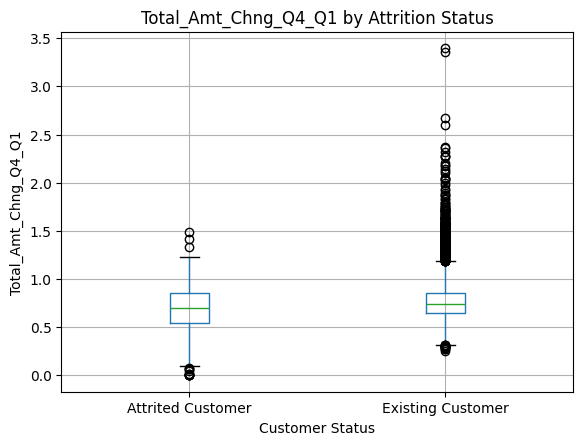

<Figure size 640x480 with 0 Axes>

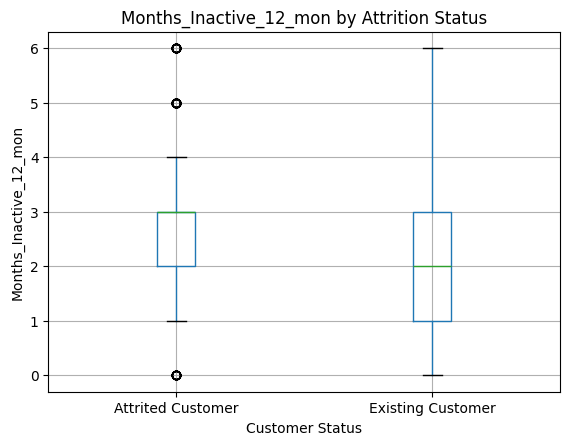

<Figure size 640x480 with 0 Axes>

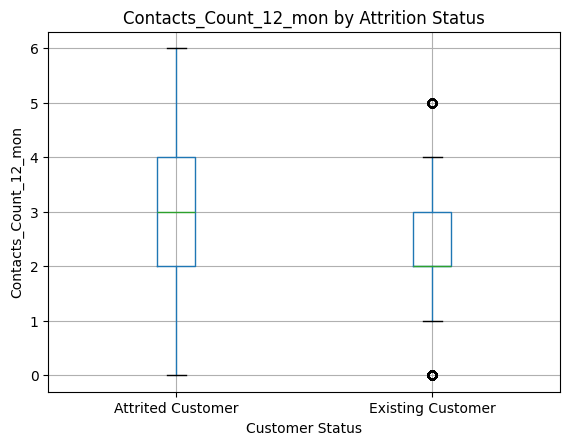

In [15]:
important_num_cols = [
    "Total_Trans_Ct",
    "Total_Trans_Amt",
    "Avg_Utilization_Ratio",
    "Total_Ct_Chng_Q4_Q1",
    "Total_Amt_Chng_Q4_Q1",
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon"
]

for col in important_num_cols:
    plt.figure()
    df.boxplot(column=col, by="Attrition_Flag")
    plt.title(f"{col} by Attrition Status")
    plt.suptitle("")
    plt.xlabel("Customer Status")
    plt.ylabel(col)
    plt.show()


### Boxplot-Based Feature Importance Interpretation

Boxplots comparing churned and non-churned customers reveal clear behavioral patterns.

- `Total_Trans_Ct` and `Total_Trans_Amt` show strong separation, with existing customers
  exhibiting substantially higher transaction frequency and spending.
- `Avg_Utilization_Ratio` is markedly lower among churned customers, indicating reduced
  credit card usage prior to attrition.
- Change-based metrics (`Total_Ct_Chng_Q4_Q1` and `Total_Amt_Chng_Q4_Q1`) highlight that
  existing customers maintain positive activity growth, while churned customers show
  stagnation or decline. These features act as early warning signals.
- Engagement indicators (`Months_Inactive_12_mon` and `Contacts_Count_12_mon`) show higher
  central values for churned customers, reflecting inactivity and customer friction.
- Although some overlap exists, the consistency of these patterns across multiple
  features confirms their strong relevance for churn prediction.

Overall, transaction behavior and engagement dynamics dominate churn discrimination,
while demographic features play a secondary role.


In [ ]:
# Mean comparison (effect size intuition)
mean_comparison = (
    df
    .groupby("Attrition_Flag")[important_num_cols]
    .mean()
    .T # Transpose for easier comparison (rows=features, cols=customer status)
)

mean_comparison["absolute_diff"] = (
    mean_comparison["Existing Customer"] -
    mean_comparison["Attrited Customer"]
).abs()

mean_comparison.sort_values("absolute_diff", ascending=False)


Attrition_Flag,Attrited Customer,Existing Customer,absolute_diff
Total_Trans_Amt,3095.025814,4654.655882,1559.630068
Total_Trans_Ct,44.933620,68.672588,23.738968
Contacts_Count_12_mon,2.972342,2.356353,0.615989
Months_Inactive_12_mon,2.693301,2.273765,0.419536
Total_Ct_Chng_Q4_Q1,0.554386,0.742434,0.188048
Avg_Utilization_Ratio,0.162475,0.296412,0.133937
Total_Amt_Chng_Q4_Q1,0.694277,0.772510,0.078233


### Feature Importance — Mean Comparison

A comparison of mean values between churned and non-churned customers reveals
clear behavioral differences.

- Existing customers exhibit significantly higher transaction activity:
  - `Total_Trans_Amt`: ~4655 vs ~3095
  - `Total_Trans_Ct`: ~69 vs ~45  
  These variables represent strong protective factors against churn.

- Change metrics show that existing customers maintain or increase activity over time:
  - `Total_Ct_Chng_Q4_Q1`: 0.74 vs 0.55
  - `Total_Amt_Chng_Q4_Q1`: 0.77 vs 0.69  
  These features act as early warning indicators of disengagement.

- Credit utilization is substantially lower among churned customers:
  - `Avg_Utilization_Ratio`: 0.16 vs 0.30  
  Suggesting reduced card usage prior to attrition.

- Engagement-related features indicate higher risk among churned customers:
  - `Months_Inactive_12_mon`: 2.69 vs 2.27
  - `Contacts_Count_12_mon`: 2.97 vs 2.36  
  Reflecting inactivity and customer friction.

Overall, transaction and engagement features dominate churn discrimination,
while demographic variables play a secondary role.


In [ ]:
# EDA-level ranking using correlation magnitude
eda_importance = (
    corr_target
    .drop("Attrition_Flag_Num")
    .abs() # Take absolute value for magnitude
    .sort_values(ascending=False)
)

eda_importance

### EDA-level Feature Importance (Correlation Magnitude)

Using absolute correlation with the churn target (`Attrition_Flag_Num`), the strongest
signals are transaction and engagement-related variables.

Top features by |correlation|:
- `Total_Trans_Ct` (0.371)
- `Total_Ct_Chng_Q4_Q1` (0.290)
- `Total_Revolving_Bal` (0.263)
- `Contacts_Count_12_mon` (0.204)
- `Avg_Utilization_Ratio` (0.178)
- `Total_Trans_Amt` (0.169)
- `Months_Inactive_12_mon` (0.152)
- `Total_Relationship_Count` (0.150)

Demographic and tenure variables show low linear correlation with churn
(e.g., age, dependents, months on book). `CLIENTNUM` is an identifier and must be excluded
despite appearing in the correlation output.

Note: correlation captures linear effects; non-linear relationships (e.g., inactivity)
may be stronger in tree-based models.


For modeling, identifier columns and precomputed model outputs were excluded to avoid data leakage.
Feature selection prioritized transaction behavior and engagement indicators, which showed the
strongest discriminative power during EDA. Demographic and tenure variables were retained as
secondary features for potential interaction effects.

In [ ]:
# Target
target = "Attrition_Flag"

# Columns to drop (ID + leakage + redundant)
drop_cols = [
    "CLIENTNUM",

    # Leakage: precomputed Naive Bayes outputs
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2",

    # Redundant credit limit features
    "Credit_Limit",
    "Avg_Open_To_Buy",
]

# Final feature set (EDA-driven)
feature_cols = [
    # Transaction behavior
    "Total_Trans_Ct",
    "Total_Trans_Amt",
    "Avg_Utilization_Ratio",
    "Total_Ct_Chng_Q4_Q1",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Revolving_Bal",

    # Engagement & relationship
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon",
    "Total_Relationship_Count",

    # Demographic / tenure (secondary)
    "Customer_Age",
    "Months_on_book",
    "Dependent_count",
]

categorical_features = [ # Marital_Status --> weak signal (we saw it in EDA)
    "Gender",
    "Education_Level",
    "Income_Category",
    "Card_Category",
]

# Build final modeling dataframe
df_model = df[feature_cols + [target]].copy()

# Sanity checks
print("Shape:", df_model.shape)
print("\nTarget distribution:")
print(df_model[target].value_counts(normalize=True))

df_model.head()

Shape: (10127, 13)

Target distribution:
Attrition_Flag
Existing Customer    0.83934
Attrited Customer    0.16066
Name: proportion, dtype: float64


,Total_Trans_Ct,Total_Trans_Amt,Avg_Utilization_Ratio,Total_Ct_Chng_Q4_Q1,Total_Amt_Chng_Q4_Q1,Total_Revolving_Bal,Months_Inactive_12_mon,Contacts_Count_12_mon,Total_Relationship_Count,Customer_Age,Months_on_book,Dependent_count,Attrition_Flag
0,42,1144,0.061,1.625,1.335,777,1,3,5,45,39,3,Existing Customer
1,33,1291,0.105,3.714,1.541,864,1,2,6,49,44,5,Existing Customer
2,20,1887,0.000,2.333,2.594,0,1,0,4,51,36,3,Existing Customer
3,20,1171,0.760,2.333,1.405,2517,4,1,3,40,34,4,Existing Customer
4,28,816,0.000,2.500,2.175,0,1,0,5,40,21,3,Existing Customer
